In [1]:
import os
os.chdir('/zhome/71/c/146676/main/')
from helpers import module_auxiliary as ma
import numpy as np
import matplotlib.pyplot as plt
import tifffile

In [ ]:
import h5py
import hdf5plugin
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('Agg')
Nx = 362
batch_id = 50
i = 100
save_path = '/dtu-compute/msaca/sliceA_diffraction/animation/single_images/diff_trans-'
count = 0
for i in range(100,130):
    count = count+1
    with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_non_integrated/scan-0339_pilatus.h5', 'r') as file:
        # Check the keys in the file (this shows the main datasets or groups)
        all_polar3 = []
        # Access a dataset or group (replace 'your_dataset' with the correct key)
        dataset_ = file['entry']['instrument']['pilatus']['data'][Nx*batch_id + 1*i]  # Replace 'your_dataset' with the actual name of the dataset
        dataset = dataset_.astype(np.float32)

        fig, ax = plt.subplots()
        cax = ax.imshow(np.log(dataset+2.001), cmap = 'grey', vmin = -1, vmax = 4.5)
        ax.axis('off')
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
        ax.set_position([0, 0, 1, 1])
        plt.savefig( save_path + str(count) + '.png', dpi=70, bbox_inches='tight', pad_inches=0)
        plt.close('all')


In [ ]:
import h5py
import hdf5plugin
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('Agg')
Nx = 362
batch_id = 50
i = 100
save_path = '/dtu-compute/msaca/sliceA_diffraction/animation/single_images/diff_rot-'
count = 0
for i in range(100,130):
    count = count+1
    with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_non_integrated/scan-0339_pilatus.h5', 'r') as file:
        # Check the keys in the file (this shows the main datasets or groups)
        all_polar3 = []
        # Access a dataset or group (replace 'your_dataset' with the correct key)
        dataset_ = file['entry']['instrument']['pilatus']['data'][Nx*i + 100]  # Replace 'your_dataset' with the actual name of the dataset
        dataset = dataset_.astype(np.float32)

        fig, ax = plt.subplots()
        cax = ax.imshow(dataset, cmap = 'grey', vmin = 0, vmax = 10)
        ax.axis('off')
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
        ax.set_position([0, 0, 1, 1])
        plt.savefig( save_path + str(count) + '.png', dpi=70, bbox_inches='tight', pad_inches=0)
        plt.close('all')

In [7]:
from astropy.io import fits

path_pre = '/dtu-compute/msaca/sliceA_neutron_psi/OB/OB_start_#####.fits'
A = np.arange(1,31,1)
paths_OB = ma.generate_paths(path_pre, A)

path_pre = '/dtu-compute/msaca/sliceA_neutron_psi/DC/DC_#####.fits'
A = np.arange(1,31,1)
paths_DC = ma.generate_paths(path_pre, A)

path_save_raw = '/dtu-compute/msaca/sliceA_neutron_psi/animations/projection_images/image_raw-'
path_save_prep = '/dtu-compute/msaca/sliceA_neutron_psi/animations/projection_images/image_prep-'



image_ob = []
image_dc = []
for i in range(30):
    with fits.open(paths_OB[i]) as hdul:
        # Assume the data is in the primary HDU
        image_ob.append(hdul[0].data.astype(np.float32)[150:-200,200:-200])

    with fits.open(paths_DC[i]) as hdul:
        # Assume the data is in the primary HDU
        image_dc.append(hdul[0].data.astype(np.float32)[150:-200,200:-200])


ob_mean = np.mean(np.stack(image_ob),axis=0)
dc_mean = np.mean(np.stack(image_dc),axis=0)

path_pre = '/dtu-compute/msaca/sliceA_neutron_psi/ct_3x1126_60s/ct_3x1126_60s_#####.fits'
A = np.arange(1,3*1126+1,50)
paths = ma.generate_paths(path_pre, A)
count = 0
for i in range(len(A)):
    count = count+1
    with fits.open(paths[i]) as hdul:
        # Assume the data is in the primary HDU
        image = hdul[0].data.astype(np.float32)[150:-200,200:-200]

    fig, ax = plt.subplots()  # Match figure size to image
    ax.imshow(image, vmin=600, vmax=2600, cmap='inferno')
    ax.axis('off')

    # Remove all extra white space
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.set_position([0, 0, 1, 1])

    # Save without padding
    plt.savefig(path_save_raw + str(count) + '.png', dpi=70, bbox_inches='tight', pad_inches=0)

    plt.close('all')


    image_prep = np.log(np.abs((image-dc_mean)/(np.abs(ob_mean-dc_mean)+0.00001))+0.00001)
    image_prep[image_prep<-0.5] = 1

    fig, ax = plt.subplots()  # Match figure size to image
    ax.imshow(image_prep, vmin=-0.4, vmax=0.2, cmap='inferno')
    ax.axis('off')

    # Remove all extra white space
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.set_position([0, 0, 1, 1])

    # Save without padding
    plt.savefig(path_save_prep + str(count) + '.png', dpi=70, bbox_inches='tight', pad_inches=0)

    plt.close('all')



In [2]:
from loaders import loader_XA_to_NA
import SimpleITK as sitk
xray_slices = range(300,2700)
neutron_slices = range(0,1600)
output_volume = [[0,1600],[None], [None]]
reg = loader_XA_to_NA.load_subset_of_registered_data(dataset_XA='tv', dataset_NA='tv' , h=4, xray_slices = xray_slices,
    neutron_slices = neutron_slices, output_volume = output_volume)


Loading xray data
Loading neutron data
Resampling the transformation
Resampling moving image


: 

: 

In [ ]:
print(np.shape(sitk.GetArrayFromImage(reg.moving)))
print(np.shape(sitk.GetArrayFromImage(reg.fixed)))

In [2]:
XA = np.load('/dtu-compute/msaca/cache/low_res_recon/xray.npy')
NA = np.load('/dtu-compute/msaca/cache/low_res_recon/neutron.npy')

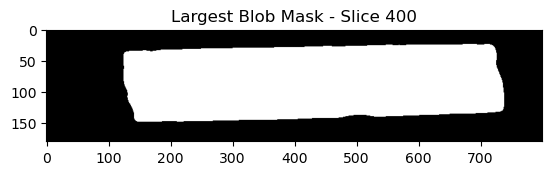

In [8]:
import scipy.ndimage as ndimage

def gaussian_smoothing(volume, sigma=1):
    return ndimage.gaussian_filter(volume, sigma=sigma)

# Step 2: Thresholding
def thresholding(volume, threshold_value):
    return volume > threshold_value

# Step 3: Blob Analysis
def find_largest_blob(binary_volume):
    # Label connected components (blobs)
    labeled_volume, num_labels = ndimage.label(binary_volume)
    
    # Calculate the size of each labeled blob
    blob_sizes = np.bincount(labeled_volume.ravel())
    
    # Ignore the background (label 0)
    blob_sizes[0] = 0
    
    # Find the label of the largest blob
    largest_blob_label = blob_sizes.argmax()
    
    # Create a mask for the largest blob
    largest_blob_mask = (labeled_volume == largest_blob_label)
    
    return largest_blob_mask


# Apply Gaussian smoothing
smoothed_volume = gaussian_smoothing(XA, sigma=5)

# Apply thresholding (e.g., threshold at 0.5)
thresholded_volume = thresholding(smoothed_volume, threshold_value=0.014)

# Find the largest blob
largest_blob_mask = find_largest_blob(thresholded_volume).astype(np.float32)

# Visualize a slice of the largest blob mask (e.g., in the middle of the volume)
slice_index = largest_blob_mask.shape[0] // 2
plt.imshow(largest_blob_mask[slice_index, :, :], cmap='gray')
plt.title("Largest Blob Mask - Slice {}".format(slice_index))
plt.show()

In [ ]:

threshold = [0.014, 0.014]
factor = 1
reg.compute_stone_boundaries(thresholds = threshold, factor = factor) # saved in reg.fixed_seg and reg.moving_seg
initial_mask = reg.fixed_seg
mask = sitk.Resample(
    initial_mask,
    reg.fixed,
    sitk.Transform(),
    sitk.sitkNearestNeighbor,  # Use nearest neighbor to preserve binary mask values
    initial_mask.GetPixelID()
)

mask = reg.as_array(mask)
fixed = reg.as_array(reg.fixed)
moving = reg.as_array(reg.moving)

In [ ]:
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use('Agg')

# Load your 3D segmentation volume (replace with actual data)
segmentation = largest_blob_mask[::4,::4,::4]  # Example binary volume

print(1)
# Extract the surface mesh using Marching Cubes
verts, faces, _, _ = measure.marching_cubes(segmentation, level=0.5)
print(2)

# Create figure and 3D plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a 3D polygon collection
print(3)
mesh = Poly3DCollection(verts[faces], alpha=0.5)
mesh.set_facecolor((0.3, 0.3, 0.7))  # Light blue
print(4)

# Add shading
mesh.set_edgecolor('k')  # Black edges
ax.add_collection3d(mesh)
print(5)

# Set view and limits based on the actual volume dimensions
ax.set_xlim(0, segmentation.shape[0])  # 200
ax.set_ylim(0, segmentation.shape[1])  # 30
ax.set_zlim(0, segmentation.shape[2])  # 200

# To ensure proper aspect ratio, manually adjust the aspect of each axis:
ax.set_box_aspect([segmentation.shape[0], segmentation.shape[1], segmentation.shape[2]])

# Set the camera view to get a good look at the structure
ax.view_init(elev=20, azim=135)  # Adjusting the angle for better depth perception

# Add lighting effects for more depth
from mpl_toolkits.mplot3d import Axes3D
ax.set_facecolor('white')  # Set background to white for better contrast

# Set light source and apply shading
ax.view_init(elev=30, azim=135)  # Adjusted to give more 3D feel

# Add custom shading
ax.set_box_aspect([segmentation.shape[0], segmentation.shape[1], segmentation.shape[2]])  # Ensure proper scaling

# Apply a light source from different angles to improve depth perception
ax.grid(False)  # Remove the grid for a cleaner look

# Save the plot
print(6)
plt.savefig('/dtu-compute/msaca/cache/Aplot.png')
plt.close('all')
print(7)



1
2
3
4
5
6
7


In [1]:
import os
os.chdir('/zhome/71/c/146676/main/')
from helpers import module_auxiliary as ma
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import h5py
import hdf5plugin
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('Agg')


In [2]:

Nx = 362
batch_id = 50
i = 100
save_path = '/dtu-compute/msaca/sliceA_diffraction/animation/integration/int-'
count = 0
for i in range(120,121):
    count = count+1
    with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_non_integrated/scan-0339_pilatus.h5', 'r') as file:
        # Check the keys in the file (this shows the main datasets or groups)
        all_polar3 = []
        # Access a dataset or group (replace 'your_dataset' with the correct key)
        dataset_ = file['entry']['instrument']['pilatus']['data'][Nx*batch_id + 1*i]  # Replace 'your_dataset' with the actual name of the dataset
        dataset_ = dataset_.astype(np.float32)


In [4]:
np.save('/dtu-compute/msaca/sliceA_diffraction/animation/example_data/detector-image.npy',dataset_)

In [ ]:
import cv2
step = 2
def cartesian_to_polar_opencv(matrix,num_phi=360,num_rad = None):
    rows, cols = matrix.shape
    bias_col = 28
    bias_row = 33
    center = (cols // 2+bias_col, rows // 2+bias_row)  # Define center as origin
    max_radius = (min(cols, rows) // 2)-210
    if num_rad is None:
        num_rad = max_radius
    # Convert Cartesian to Polar using OpenCV's warpPolar
    polar_matrix = cv2.warpPolar(
        matrix, (num_rad, num_phi), center, max_radius,
        cv2.WARP_POLAR_LINEAR + cv2.INTER_LINEAR
    )

    return polar_matrix

dataset = np.log(dataset_+2.001)
dataset__ = np.pad(dataset_,pad_width=((600, 600), (600, 600)))
polar_matrix = cartesian_to_polar_opencv(dataset__)


dataset_p = np.log(polar_matrix+2.001)


In [ ]:

img=dataset
for i in range(0,360,step):
    angle_deg = -i
    angle_rad = np.deg2rad(angle_deg)

    # Image center
    center_y, center_x = img.shape[0] / 2+28, img.shape[1] / 2+33

    # Big enough length to reach all edges
    length = max(img.shape) * 2  # overshoot to be safe

    # Compute endpoints of the line (in both directions)
    dx = length * np.cos(angle_rad)
    dy = length * np.sin(angle_rad)

    x_start = center_x
    y_start = center_y
    x_end   = center_x + dx
    y_end   = center_y + dy

    # Plot

    fig, ax = plt.subplots()
    ax.imshow(img, cmap='gray', vmin=-0.2, vmax = 4.5)
    ax.plot([x_start, x_end], [y_start, y_end], color='red', linewidth=3)
    plt.xlim(0, img.shape[1])
    plt.ylim(img.shape[0], 0)  # invert y-axis because imshow has origin at upper left

    ax.axis('off')
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.set_position([0, 0, 1, 1])
    plt.savefig('/dtu-compute/msaca/sliceA_diffraction/animation/integration/im-' + str(i//step) + '.png', dpi=70, bbox_inches='tight', pad_inches=0)
    plt.close('all')



In [8]:
from scipy.ndimage import map_coordinates
# Create output Cartesian grid (square)
def polar_to_cartesian(polar_matrix):
    n_theta, n_radius = np.shape(polar_matrix)
    cart_size = 2 * n_radius
    x = np.linspace(-n_radius, n_radius, cart_size)
    y = np.linspace(-n_radius, n_radius, cart_size)
    X, Y = np.meshgrid(x, y)

    # Convert Cartesian (X, Y) to polar (r, theta_index)
    R = np.sqrt(X**2 + Y**2)
    Theta = np.arctan2(-Y, X)  # negative Y to match imshow's top-down orientation
    Theta[Theta < 0] += 2 * np.pi

    # Normalize theta and radius to pixel indices in polar image
    theta_idx = Theta / (2 * np.pi) * (n_theta - 1)
    radius_idx = R / R.max() * (n_radius - 1)

    # Stack indices for interpolation
    coords = np.stack([theta_idx, radius_idx])

    # Interpolate
    cartesian = map_coordinates(polar_matrix, coords, order=1, mode='constant', cval=0.0)
    return cartesian

In [6]:
step = 2

nx, ny = np.shape(dataset_p)
dataset_p_cumsum = np.cumsum(np.flipud(polar_matrix),axis=0)
plt.show()
theta = np.linspace(0,18.5,ny)

for i in range(0,360,step):

    plt.plot(theta,dataset_p_cumsum[i], color='red', linewidth=3)
    plt.xlabel('2' + r'$\theta$')
    plt.ylim([0,3820])
    for spine in plt.gca().spines.values():
        spine.set_visible(False)

    plt.gca().xaxis.set_ticks_position('bottom')
    plt.gca().yaxis.set_ticks_position('left')
    plt.savefig('/dtu-compute/msaca/sliceA_diffraction/animation/integration/int-' + str(i//step) + '.png')
    plt.close('all')


In [17]:
q_values = np.quantile(polar_matrix, q=0.82, axis=0)
polar_powder = np.clip(polar_matrix, 0, q_values)
polar_crystal = polar_matrix - polar_powder
cart_powder = polar_to_cartesian(polar_powder)[:,50:-120]
cart_crystal = polar_to_cartesian(polar_crystal)[:,50:-120]
cart_crystal_ = np.log(cart_crystal+2.001)
cart_powder_ = np.log(cart_powder+2.001)

In [22]:
img = cart_crystal_
for i in range(0,360,step):
    angle_deg = -i
    angle_rad = np.deg2rad(angle_deg)

    # Image center
    center_y, center_x = img.shape[0] / 2+4, img.shape[1] / 2+53

    # Big enough length to reach all edges
    length = max(img.shape) * 2  # overshoot to be safe

    # Compute endpoints of the line (in both directions)
    dx = length * np.cos(angle_rad)
    dy = length * np.sin(angle_rad)

    x_start = center_x
    y_start = center_y
    x_end   = center_x + dx
    y_end   = center_y + dy

    # Plot

    fig, ax = plt.subplots()
    ax.imshow(img, cmap='gray', vmin=-0.2, vmax = 4.5)
    ax.plot([x_start, x_end], [y_start, y_end], color='red', linewidth=3)
    plt.xlim(0, img.shape[1])
    plt.ylim(img.shape[0], 0)  # invert y-axis because imshow has origin at upper left

    ax.axis('off')
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.set_position([0, 0, 1, 1])
    plt.savefig('/dtu-compute/msaca/sliceA_diffraction/animation/integration/im-crystal-' + str(i//step) + '.png', dpi=70, bbox_inches='tight', pad_inches=0)
    plt.close('all')

In [24]:
step = 2

nx, ny = np.shape(dataset_p)
dataset_p_cumsum = np.cumsum(np.flipud(polar_crystal),axis=0)
plt.show()
theta = np.linspace(0,18.5,ny)

for i in range(0,360,step):

    plt.plot(theta,dataset_p_cumsum[i], color='red', linewidth=3)
    plt.xlabel('2' + r'$\theta$')
    plt.ylim([0,1220])
    for spine in plt.gca().spines.values():
        spine.set_visible(False)

    plt.gca().xaxis.set_ticks_position('bottom')
    plt.gca().yaxis.set_ticks_position('left')
    plt.savefig('/dtu-compute/msaca/sliceA_diffraction/animation/integration/int-crystal-' + str(i//step) + '.png')
    plt.close('all')


In [ ]:
plt.figure()
plt.imshow(cart_powder_, vmin=0, vmax = 4.5)
plt.savefig('/dtu-compute/msaca/cache/plot.png')
plt.close('all')

In [ ]:
        fig, ax = plt.subplots()
        cax = ax.imshow(np.log(dataset+2.001), cmap = 'grey', vmin = -1, vmax = 4.5)
        ax.axis('off')
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
        ax.set_position([0, 0, 1, 1])
        plt.savefig( save_path + str(count) + '.png', dpi=70, bbox_inches='tight', pad_inches=0)
        plt.close('all)')

In [ ]:
import os
os.chdir('/zhome/71/c/146676/main/')
from helpers import module_auxiliary as ma
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import h5py
import hdf5plugin
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('Agg')
from matplotlib_scalebar.scalebar import ScaleBar
from loaders import loader_XA_to_NA
import SimpleITK as sitk

In [113]:
xray_slices = range(0,2800)
neutron_slices = range(0,1650)
output_volume = [[0,1650],[None], [None]]
reg = loader_XA_to_NA.load_subset_of_registered_data(dataset_XA='fbp', dataset_NA='dtv', h=1.8, xray_slices = xray_slices,
    neutron_slices = neutron_slices, output_volume = output_volume)

Loading xray data
Loading neutron data
Resampling the transformation
Resampling moving image


In [ ]:

#images_xray = sitk.GetArrayFromImage(reg.moving)
#images_neutron = sitk.GetArrayFromImage(reg.fixed)

In [105]:
image = images_xray[400:-300,300,300:-100]
fig, ax = plt.subplots()
im = ax.imshow(image, cmap='gray', vmin=-0.02, vmax = 0.06)

# Add scalebar — units per pixel must be known
scalebar = ScaleBar(3.2,               # 0.5 µm per pixel
                    units='µm',
                    location='lower left',
                    color='lightgray',
                    box_alpha=0.01,     # Semi-transparent background
                    scale_loc='bottom',# Puts the label below the bar
                    frameon=False,     # Removes border
                    border_pad=0.5)    # Tight spacing

ax.add_artist(scalebar)
ax.set_axis_off()
plt.tight_layout()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.set_position([0, 0, 1, 1])
plt.show()
#'/dtu-compute/msaca/sliceA_neutron_psi/animations/reconstruction_images/
plt.savefig('/dtu-compute/msaca/sliceA_xray_pc/animation_images/reconstruction_images/fbp/XA-highres-fbp.png', dpi=350,bbox_inches='tight', pad_inches=0)
plt.close('all')

In [106]:
image = images_xray[1000:1400,300,1000:1400]
fig, ax = plt.subplots()
im = ax.imshow(image, cmap='gray', vmin=-0.02, vmax = 0.06)

# Add scalebar — units per pixel must be known
scalebar = ScaleBar(3.2,               # 0.5 µm per pixel
                    units='µm',
                    location='lower left',
                    color='lightgray',
                    box_alpha=0.01,     # Semi-transparent background
                    scale_loc='bottom',# Puts the label below the bar
                    frameon=False,     # Removes border
                    border_pad=0.5)    # Tight spacing

ax.add_artist(scalebar)
ax.set_axis_off()
plt.tight_layout()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.set_position([0, 0, 1, 1])
plt.show()
#'/dtu-compute/msaca/sliceA_neutron_psi/animations/reconstruction_images/
plt.savefig('/dtu-compute/msaca/sliceA_xray_pc/animation_images/reconstruction_images/fbp/XA-zoom-highres-fbp.png', dpi=350,bbox_inches='tight', pad_inches=0)
plt.close('all')

In [115]:
image = images_neutron[400:-300,300,300:-100]

fig, ax = plt.subplots()
im = ax.imshow(image, cmap='gray', vmin=-0.02, vmax = 0.06)

# Add scalebar — units per pixel must be known
scalebar = ScaleBar(3.2,               # 0.5 µm per pixel
                    units='µm',
                    location='lower left',
                    color='lightgray',
                    box_alpha=0.01,     # Semi-transparent background
                    scale_loc='bottom',# Puts the label below the bar
                    frameon=False,     # Removes border
                    border_pad=0.5)    # Tight spacing

ax.add_artist(scalebar)
ax.set_axis_off()
plt.tight_layout()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.set_position([0, 0, 1, 1])
plt.show()
#'/dtu-compute/msaca/sliceA_neutron_psi/animations/reconstruction_images/
plt.savefig('/dtu-compute/msaca/sliceA_neutron_psi/animations/reconstruction_images/dtv/NA-highres-dtv.png', dpi=350,bbox_inches='tight', pad_inches=0)
plt.close('all')

In [116]:
image = images_neutron[1000:1400,300,1000:1400]
fig, ax = plt.subplots()
im = ax.imshow(image, cmap='gray', vmin=-0.02, vmax = 0.06)

# Add scalebar — units per pixel must be known
scalebar = ScaleBar(3.2,               # 0.5 µm per pixel
                    units='µm',
                    location='lower left',
                    color='lightgray',
                    box_alpha=0.01,     # Semi-transparent background
                    scale_loc='bottom',# Puts the label below the bar
                    frameon=False,     # Removes border
                    border_pad=0.5)    # Tight spacing

ax.add_artist(scalebar)
ax.set_axis_off()
plt.tight_layout()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.set_position([0, 0, 1, 1])
plt.show()
#'/dtu-compute/msaca/sliceA_neutron_psi/animations/reconstruction_images/
plt.savefig('/dtu-compute/msaca/sliceA_neutron_psi/animations/reconstruction_images/dtv/NA-zoom-highres-dtv.png', dpi=350,bbox_inches='tight', pad_inches=0)
plt.close('all')

In [109]:
slices = np.arange(140,480,5)
for i in range(len(slices)):
    image = images_xray[400:-300,slices[i],300:-100]

    fig, ax = plt.subplots()
    im = ax.imshow(image, cmap='gray', vmin=-0.02, vmax = 0.06)

    # Add scalebar — units per pixel must be known
    scalebar = ScaleBar(3.2,               # 0.5 µm per pixel
                        units='µm',
                        location='lower left',
                        color='lightgray',
                        box_alpha=0.01,     # Semi-transparent background
                        scale_loc='bottom',# Puts the label below the bar
                        frameon=False,     # Removes border
                        border_pad=0.5)    # Tight spacing

    ax.add_artist(scalebar)
    ax.set_axis_off()
    plt.tight_layout()
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.set_position([0, 0, 1, 1])
    plt.show()
    
    plt.savefig('/dtu-compute/msaca/sliceA_xray_pc/animation_images/reconstruction_images/fbp/XA-fbp-' + str(i) + '.png', dpi=200,bbox_inches='tight', pad_inches=0)
    plt.close('all')




In [110]:
slices = np.arange(140,480,5)
for i in range(len(slices)):
    image = images_xray[1000:1400,slices[i],1000:1400]

    fig, ax = plt.subplots()
    im = ax.imshow(image, cmap='gray', vmin=-0.02, vmax = 0.06)

    # Add scalebar — units per pixel must be known
    scalebar = ScaleBar(3.2,               # 0.5 µm per pixel
                        units='µm',
                        location='lower left',
                        color='lightgray',
                        box_alpha=0.01,     # Semi-transparent background
                        scale_loc='bottom',# Puts the label below the bar
                        frameon=False,     # Removes border
                        border_pad=0.5)    # Tight spacing

    ax.add_artist(scalebar)
    ax.set_axis_off()
    plt.tight_layout()
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.set_position([0, 0, 1, 1])
    plt.show()
    
    plt.savefig('/dtu-compute/msaca/sliceA_xray_pc/animation_images/reconstruction_images/fbp/XA-zoom-fbp-' + str(i) + '.png', dpi=200,bbox_inches='tight', pad_inches=0)
    plt.close('all')


In [117]:

slices = np.arange(140,480,5)
for i in range(len(slices)):
    image = images_neutron[400:-300,slices[i],300:-100]

    fig, ax = plt.subplots()
    im = ax.imshow(image, cmap='gray', vmin=-0.02, vmax = 0.06)

    # Add scalebar — units per pixel must be known
    scalebar = ScaleBar(3.2,               # 0.5 µm per pixel
                        units='µm',
                        location='lower left',
                        color='lightgray',
                        box_alpha=0.01,     # Semi-transparent background
                        scale_loc='bottom',# Puts the label below the bar
                        frameon=False,     # Removes border
                        border_pad=0.5)    # Tight spacing

    ax.add_artist(scalebar)
    ax.set_axis_off()
    plt.tight_layout()
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.set_position([0, 0, 1, 1])
    plt.show()
    
    plt.savefig('/dtu-compute/msaca/sliceA_neutron_psi/animations/reconstruction_images/dtv/NA-dtv-' + str(i) + '.png', dpi=200,bbox_inches='tight', pad_inches=0)
    plt.close('all')



In [118]:

slices = np.arange(140,480,5)
for i in range(len(slices)):
    image = images_neutron[1000:1400,slices[i],1000:1400]

    fig, ax = plt.subplots()
    im = ax.imshow(image, cmap='gray', vmin=-0.02, vmax = 0.06)

    # Add scalebar — units per pixel must be known
    scalebar = ScaleBar(3.2,               # 0.5 µm per pixel
                        units='µm',
                        location='lower left',
                        color='lightgray',
                        box_alpha=0.01,     # Semi-transparent background
                        scale_loc='bottom',# Puts the label below the bar
                        frameon=False,     # Removes border
                        border_pad=0.5)    # Tight spacing

    ax.add_artist(scalebar)
    ax.set_axis_off()
    plt.tight_layout()
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.set_position([0, 0, 1, 1])
    plt.show()
    
    plt.savefig('/dtu-compute/msaca/sliceA_neutron_psi/animations/reconstruction_images/dtv/NA-zoom-dtv-' + str(i) + '.png', dpi=200,bbox_inches='tight', pad_inches=0)
    plt.close('all')
